## 2.4 양자 진폭 증폭 (Quantum Amplitude Amplification, QAA)

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import GroverOperator
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 원하는 상태에 대한 오라클 정의 (여기서는 |11> 을 찾는다고 하자)
def oracle():
    qc = QuantumCircuit(2)
    qc.cz(0, 1)
    return qc

In [3]:
# 확산 연산자(그로버 연산자) 정의
def diffusion_operator():
    qc = QuantumCircuit(2)
    qc.h([0, 1])
    qc.z([0, 1])
    qc.cz(0, 1)
    qc.h([0, 1])
    return qc

In [4]:
# QAA를 위한 양자 회로 생성
qc = QuantumCircuit(2, 2)
qc.h([0, 1])  # 하다마드 게이트로 중첩 상태로 초기화

In [5]:
# 오라클과 확산 연산자 적용
oracle_circuit = oracle()
diffusion_circuit = diffusion_operator()
grover_operator = GroverOperator(oracle_circuit)

qc.append(grover_operator, [0, 1])
qc.append(diffusion_circuit, [0, 1])
# 참고: GroverOperator(oracle())는 이미 오라클+확산을 포함한 한 번의 그로버 반복이다.
#       여기에 확산을 또 더하면 과회전이 일어날 수 있다. (이론 노트 2.4 참고)

/sessions/eloquent-vigilant-lovelace/tmp/ipykernel_91/2878939192.py:4: DeprecationWarning: The class ``qiskit.circuit.library.grover_operator.GroverOperator`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.grover_operator instead.
  grover_operator = GroverOperator(oracle_circuit)


In [6]:
# 측정 추가
qc.measure([0, 1], [0, 1])

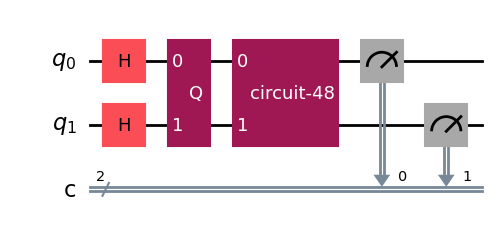

In [7]:
# 회로 그리기
qc.draw('mpl')
plt.show()

In [8]:
# AerSimulator로 회로 시뮬레이션
simulator = AerSimulator()
qc = transpile(qc, simulator)
result = simulator.run(qc, shots=1024).result()

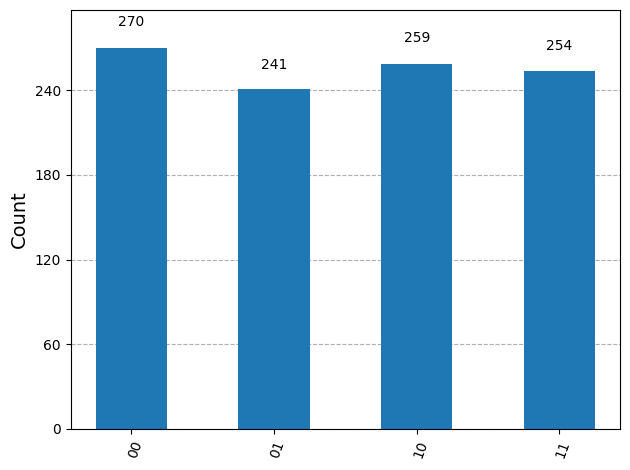

In [9]:
# 결과를 얻어 시각화
counts = result.get_counts(qc)
plot_histogram(counts)
plt.show()